In [ ]:
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import pandas as pd
#import matplotlib.pyplot as plt

from preprocessing_old import Preprocessor
from plotting_old import Plotter

from sklearn.neural_network import MLPRegressor

#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

In [4]:
#These seem to generalize well to other benchmarks as well
good_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']# R² 98% and 3,15% for the workflow data which is crazy

target = "interval_energy"

#DATA_PATH = "../../workflows/siena12/stressng-custom-1782744477/datasets/process_interval_data.parquet"
#DATA_PATH = "../../workflows/siena12/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"
DATA_PATH = "../../workflows/siena12/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"

#DATA_PATH = "../../workflows/gpu06/stressng-custom-1782751694/datasets/process_interval_data.parquet"
data = pd.read_parquet(DATA_PATH)
print("Loading data...")


Loading data...


In [5]:
data.shape

(9326973, 32)

In [6]:
class ModelBuilder():

    def __init__(self, X, y, times, alg_name="rf"):
        self.X = X
        self.y = y
        self.times = times
        self.alg_name = alg_name

    def _split(self):
        self.X_train, self.X_test, self.y_train, self.y_test, self.t_train, self.t_test = train_test_split(self.X, self.y, self.times, test_size=0.2, shuffle=False)

    def _scale(self):
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

    def _train(self):
        if self.alg_name.lower() =="rf":
            self.model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        elif self.alg_name.lower() == "mlp":
            #Currently best option for stressng 5 minute
            self.model = MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.001,
                    max_iter=200,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)
        elif self.alg_name.lower() == "mlp_optuna":
            self.model = MLPRegressor(hidden_layer_sizes=(128),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.00024,
                    max_iter=500,
                    alpha = 0.0000675,
                    #batch_size=64,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)

        else:
            print("No algorithm stored")
        
        self.model.fit(self.X_train_scaled, self.y_train)
    
    def _test(self):
        self.y_pred = self.model.predict(self.X_test_scaled)
    
    def _evaluate(self):
        r2 = r2_score(self.y_test, self.y_pred)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        mean_energy = self.y_test.mean()
        mae_pct = (mae / mean_energy) * 100
        
        #print(f"Random Forest: [{self.X_test_scaled.columns}]")
        
        if self.alg_name.lower() =="rf":
            print(f" Random Forest")
        elif self.alg_name.lower() == "mlp":
            print(f" MLP Neural Network ")
        elif self.alg_name.lower() == "mlp_optuna":
            print(f" MLP Neural Network Optuna ")
        else:
            print("No algorithm stored")

        print(f"  R² Score:  {r2:.4f}")
        print(f"  MAE:       {mae:.2f} Wh ({mae_pct:.2f}% of mean)")
        print("-" * 34)

    def _save_model(self,path, filename):
        filepath = os.path.join(path, filename)
        bundle = {
            "scaler": self.scaler,
            "model": self.model
        }        
        joblib.dump(bundle, filepath)
        print(f"Model and scaler successfully saved to: {filepath}")
    
    def run_model(self,):
        self._split()
        self._scale()
        self._train()
        self._test()
        self._evaluate()
        return self.y_pred, self.y_test, self.t_test
        
    
    def run_and_save_model(self, path="./"):
        if self.alg_name.lower() =="rf":
            model_name="random_forest.joblib"
        elif self.alg_name.lower() == "mlp":
            model_name="mlp.joblib"
        elif self.alg_name.lower() == "mlp_optuna":
            model_name="mlp.joblib"
        else:
            print("No algorithm stored")
        self._split()
        self._scale()
        self._train()
        self._test()
        self._evaluate()
        self._save_model(path, model_name)
        return self.X_test, self.y_pred, self.y_test, self.t_test

    

In [8]:
preprocessor = Preprocessor(data, good_features)
X, y, times = preprocessor.preprocess()

 MLP Neural Network 
  R² Score:  0.3923
  MAE:       5.58 Wh (3.08% of mean)
----------------------------------
Model and scaler successfully saved to: ./mlp.joblib
Predicted (Random )


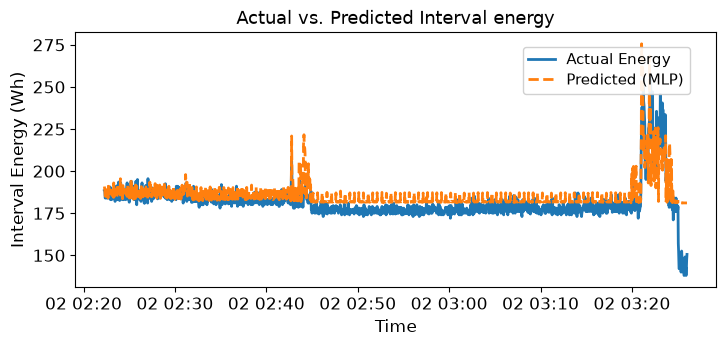

In [73]:
# Training the mlp neural network model 
full_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']


alg_name1="mlp"
builder_mlp = ModelBuilder(X, y, times, alg_name1)
#Training data

X_test1, y_pred1, y_test1, t_test1 = builder_mlp.run_and_save_model()
plotter = Plotter(y_pred=y_pred1,y_test=y_test1, t_test= t_test1,alg_name=alg_name1)
#plotter = Plotter(y_pred=y_pred1,y_test=y_test1, t_test= t_test1,alg_name=alg_name1, window_start =0, window_end=250)

plotter.plot_only("mlp_")


In [ ]:
import optuna
import numpy as np

# Train-test split.
X_train1, X_test1,y_train1,y_test1, t_train1, t_test1 = train_test_split(X, y, times, test_size=0.2, shuffle=False)

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = [trial.suggest_int(f'n_units_l{i}', 32, 128) for i in range(n_layers)]
    activation = trial.suggest_categorical('activation', ['relu','logistic', 'tanh']) #?
    lr = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-3, log=True)

    scaler = StandardScaler()
    X_train_scaled1 = scaler.fit_transform(X_train1)
    X_test_scaled1 = scaler.transform(X_test1)

    model = MLPRegressor(
            hidden_layer_sizes=tuple(layers),
            activation=activation,
            solver=solver,
            learning_rate_init=lr,
            alpha=alpha,
            max_iter=1000,        
            early_stopping=True,
            batch_size=256,  
            random_state=42
        )
    model.fit(X_train_scaled1, y_train1)
    score = model.score(X_test_scaled1, y_test1) # R² Score

    if trial.should_prune():
        raise optuna.TrialPruned()
    
    return score

    

study = optuna.create_study(
    direction='maximize',
    #pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=10),
)

study.optimize(objective, n_trials=3) 

print("Optimization complete!")
print("Best R² Score:", study.best_value)
print("Best parameters:", study.best_params)

 MLP Neural Network Optuna 
  R² Score:  0.5570
  MAE:       4.07 Wh (2.25% of mean)
----------------------------------
Model and scaler successfully saved to: ./mlp.joblib
Predicted (Random )


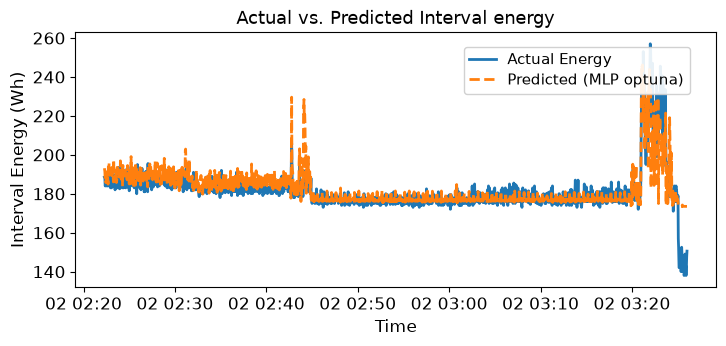

In [9]:
# Training the mlp neural network model 
#full_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']


#preprocessor = Preprocessor(data, good_features)
#X, y, times = preprocessor.preprocess()
alg_name1op="mlp_optuna"
builder_mlp_optuna = ModelBuilder(X, y, times, alg_name1op)
#Training data

X_test1op, y_pred1op, y_test1op, t_test1op = builder_mlp_optuna.run_and_save_model()
plotter = Plotter(y_pred=y_pred1op,y_test=y_test1op, t_test= t_test1op,alg_name=alg_name1op)

plotter.plot_only("mlp_optuna_")


Predicted (Random )


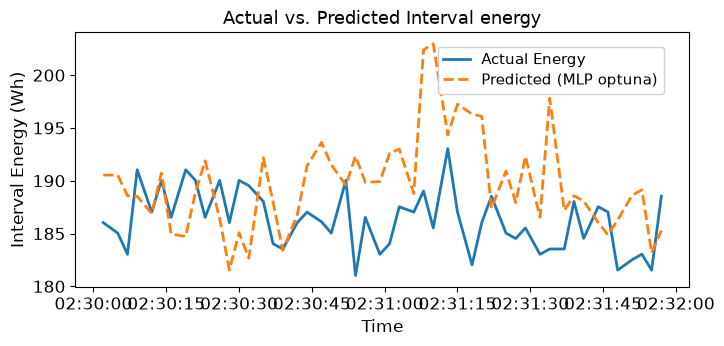

In [15]:
plotter = Plotter(y_pred=y_pred1op,y_test=y_test1op, t_test= t_test1op,alg_name=alg_name1op, window_start =200, window_end=250)

plotter.plot_and_save("mlp_optuna_small_")

In [84]:
#Preprocessing

preprocessor = Preprocessor(data, good_features)
X2, y2, times2 = preprocessor.preprocess()


 Random Forest
  R² Score:  0.0770
  MAE:       4.82 Wh (2.66% of mean)
----------------------------------
Model and scaler successfully saved to: ./random_forest.joblib
Predicted (Random )


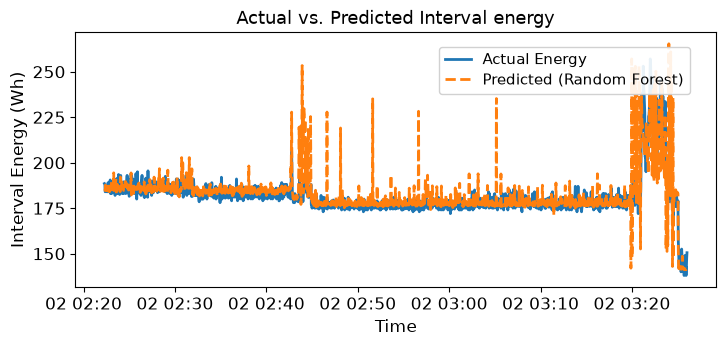

In [85]:
# Training the rf model 

alg_name3="rf"
builder_rf = ModelBuilder(X2, y2, times2, alg_name3)
#Training data

X_test3, y_pred3, y_test3, t_test3 = builder_rf.run_and_save_model()
 #Plotting the rf results

#plotter = Plotter(y_pred2,y_test2, t_test2, alg_name=alg_name, window_start =200, window_end=250)
plotter = Plotter(y_pred3,y_test3, t_test3, alg_name=alg_name3)

plotter.plot_only("rf_")

In [ ]:
plotter = Plotter(y_pred3,y_test3, t_test3, alg_name=alg_name3, window_start =1200, window_end=1500)
plotter.plot_only("rf_")


In [ ]:
plotter.plot_and_save("rf_")